In [22]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [23]:
from src.utils.dataframe_utils import create_dataframe

df_train = create_dataframe("../data/train.csv", "../data/boneage-training-dataset", segmented=False)
df_val = create_dataframe("../data/validation.csv", "../data/boneage-test-dataset", segmented=False)
df_train_seg = create_dataframe("../data/train.csv", "../data/boneage-training-segmented", segmented=True)
df_val_seg = create_dataframe("../data/validation.csv", "../data/boneage-validation-segmented", segmented=True)

In [24]:
from sklearn.preprocessing import StandardScaler

def scaling_data_torch(df, df_val):

    labels = df[["boneage"]].values.astype("float32")
    
    labels_val = df_val[["boneage"]].values.astype("float32")

    scaler =StandardScaler()
    scaler.fit(labels)

    df[["boneage"]] = scaler.transform(labels)
    df_val[["boneage"]]= scaler.transform(labels_val)

    return df, df_val, scaler




In [25]:
df_train, df_val, scaler = scaling_data_torch(df_train, df_val)
df_train_seg, df_val_seg, scaler_seg = scaling_data_torch(df_train_seg, df_val_seg)

In [26]:
df_train

,id,boneage,male,path
0,1377,1.279231,False,../data/boneage-training-dataset/1377.png
1,1378,-2.800380,False,../data/boneage-training-dataset/1378.png
2,1379,-0.809141,False,../data/boneage-training-dataset/1379.png
3,1380,-0.177773,True,../data/boneage-training-dataset/1380.png
4,1381,-1.100542,False,../data/boneage-training-dataset/1381.png
...,...,...,...,...
12606,15605,-1.877611,False,../data/boneage-training-dataset/15605.png
12607,15606,-0.347757,False,../data/boneage-training-dataset/15606.png
12608,15608,-1.756194,False,../data/boneage-training-dataset/15608.png
12609,15609,0.550729,True,../data/boneage-training-dataset/15609.png


In [27]:
import numpy as np
import torch
from PIL import Image
import torchvision.transforms.functional as TF


def load_segmented_rgb_test(path, size=(224, 224)):

    # 1. read RGBA
    img = Image.open(path).convert("RGBA")
    img = img.resize(size)

    img = np.array(img).astype(np.float32) / 255.0  # [H,W,4]

    rgb = img[..., :3]
    alpha = img[..., 3:4]   # keep channel dim

    # 2. remove background using alpha
    rgb = rgb * alpha

    # 3. back to tensor CHW
    #rgb = torch.tensor(rgb, dtype=torch.float32).permute(2, 0, 1)

    return rgb

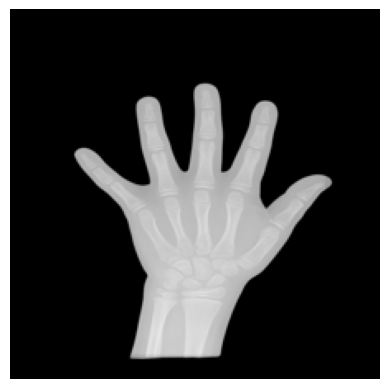

In [28]:
img = load_segmented_rgb_test("../data/boneage-trainIng-segmented/1379_seg.png")
from matplotlib import pyplot as plt

plt.imshow(img)
plt.axis("off")
plt.show()


In [29]:
img.shape

(224, 224, 3)

In [30]:
def load_segmented_rgb_test(path, size=(224, 224)):

    # 1. read RGBA
    img = Image.open(path).convert("RGBA")
    img = img.resize(size)

    img = np.array(img).astype(np.float32) / 255.0  # [H,W,4]

    rgb = img[..., :3]
    alpha = img[..., 3:4]   # keep channel dim

    # 2. remove background using alpha
    rgb = rgb * alpha

    # 3. back to tensor CHW
    rgb = torch.tensor(rgb, dtype=torch.float32).permute(2, 0, 1)

    return rgb


In [31]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np



class BoneAgeDataset(Dataset):

    def __init__(self, df, df_seg, transform=None):

        self.df = df.reset_index(drop=True).copy()
        self.df_seg = df_seg.reset_index(drop=True).copy()

        if not self.df["id"].equals(self.df_seg["id"]):
            raise ValueError("df e df_seg non sono allineati sugli id.")

        self.transform = transform

    def __len__(self):
        return len(self.df)

    @staticmethod
    def load_segmented(path):
        """
        Legge un PNG RGBA, applica il canale alpha e restituisce
        una PIL.Image RGB con lo sfondo rimosso.
        """

        rgba = np.array(Image.open(path).convert("RGBA"))

        rgb = rgba[..., :3].astype(np.float32)

        alpha = rgba[..., 3:4].astype(np.float32) / 255.0

        rgb = (rgb * alpha).astype(np.uint8)

        return Image.fromarray(rgb)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]
        row_seg = self.df_seg.iloc[idx]

        # immagine originale
        image = Image.open(row["path"]).convert("RGB")

        # immagine segmentata (RGB con alpha applicato)
        segmented = self.load_segmented(row_seg["path"])

        if self.transform is not None:
            image = self.transform(image)
            segmented = self.transform(segmented)

        sample = {
            "image": image,
            "segmented": segmented,
            "male": torch.tensor([float(row["male"])], dtype=torch.float32),
            "boneage": torch.tensor([float(row["boneage"])], dtype=torch.float32),
            "id": int(row["id"])
        }

        return sample

In [32]:
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = BoneAgeDataset(df_train, df_train_seg, transform=transform)
val_dataset = BoneAgeDataset(df_val, df_val_seg, transform=transform)

In [33]:
sample = train_dataset[0]


In [34]:
sample["image"].shape



torch.Size([3, 224, 224])

In [35]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
device

device(type='cuda')

In [38]:
import torch
import torch.nn as nn
from torchvision import models

def get_resnet18():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Identity()
    return model

In [39]:
class Backbone(nn.Module):

    def __init__(self):
        super().__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        self.features = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4,
            resnet.avgpool
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return x
    
class BoneAgeModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone_img = Backbone()
        self.backbone_seg = Backbone()

        self.fusion = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, image, segmented, male):

        f1 = self.backbone_img(image)
        f2 = self.backbone_seg(segmented)

        x = torch.cat([f1, f2], dim=1)

        x = self.fusion(x)

        return x.squeeze(1)

In [40]:
model = BoneAgeModel().to(device)
print(model)

BoneAgeModel(
  (backbone_img): Backbone(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(6

In [41]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader

import numpy as np
import os
import copy
from tqdm import tqdm


# =========================
# EARLY STOPPING
# =========================

class EarlyStopping:

    def __init__(self, patience=10, min_delta=0.0):

        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = np.inf
        self.counter = 0
        self.best_model = None

    def step(self, val_loss, model):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss
            self.counter = 0
            self.best_model = copy.deepcopy(model.state_dict())

            return True  # improvement

        else:
            self.counter += 1

            return False

    def should_stop(self):
        return self.counter >= self.patience


# =========================
# METRICS
# =========================

def mae_months(pred, target, scaler):

    # inverse transform (standardized → months)
    pred = pred * scaler.scale_[0] + scaler.mean_[0]
    target = target * scaler.scale_[0] + scaler.mean_[0]

    return torch.mean(torch.abs(pred - target)).item()


# =========================
# TRAIN ONE EPOCH
# =========================

def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()
    total_loss = 0

    for batch in tqdm(loader):

        image = batch["image"].to(device)
        seg = batch["segmented"].to(device)
        male = batch["male"].to(device)
        y = batch["boneage"].to(device)

        optimizer.zero_grad()

        pred = model(image, seg, male)

        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


# =========================
# VALIDATION
# =========================

def validate(model, loader, criterion, device, scaler):

    model.eval()

    total_loss = 0
    total_mae = 0

    with torch.no_grad():

        for batch in loader:

            image = batch["image"].to(device)
            seg = batch["segmented"].to(device)
            male = batch["male"].to(device)
            y = batch["boneage"].to(device)

            pred = model(image, seg, male)

            loss = criterion(pred, y)

            total_loss += loss.item()

            total_mae += mae_months(pred, y, scaler)

    return total_loss / len(loader), total_mae / len(loader)


# =========================
# MAIN TRAIN LOOP
# =========================

def train_model(
    model,
    train_loader,
    val_loader,
    scaler,
    device,
    epochs=50,
    lr=1e-4,
    save_path="best_model.pt"
):

    model = model.to(device)

    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.SmoothL1Loss()

    early_stopper = EarlyStopping(patience=10, min_delta=1e-4)

    best_val_loss = np.inf

    for epoch in range(epochs):

        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_loss, val_mae = validate(
            model, val_loader, criterion, device, scaler
        )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val MAE (months): {val_mae:.2f}"
        )

        # =========================
        # SAVE BEST MODEL
        # =========================

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(model.state_dict(), save_path)

            print(f"✔ Saved best model (loss {val_loss:.4f})")

        # =========================
        # EARLY STOPPING
        # =========================

        early_stopper.step(val_loss, model)

        if early_stopper.should_stop():

            print("⛔ Early stopping triggered")

            break

    # restore best model
    model.load_state_dict(early_stopper.best_model)

    return model

In [42]:
model = BoneAgeModel()

trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    scaler=scaler,
    device="cuda",
    epochs=50,
    lr=1e-4,
    save_path="best_model.pt"
)

  0%|          | 0/395 [00:00<?, ?it/s]c:\Users\silvi\Desktop\BoneAge\.venv\Lib\site-packages\torch\nn\modules\loss.py:1040: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)
  1%|▏         | 5/395 [00:25<33:42,  5.19s/it]


KeyboardInterrupt: 